In [51]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd

path = "/home/usuario/Madgraph/projects/gg_hh-LQs/"
signal = up.open(path + "signal/Events/run_01_decayed_1/tag_1_delphes_events.root")

signal_tree = signal["Delphes"]

In [34]:
# Aca uso la categoria Particle, de modo de obtener los decaimientos hasta el
# nivel de Pythia8. Si bien Delphes es quien arma el ROOT, en particles se guarda
# la informacion a nivel generacion. 

# Por otra parte, si uso Jet.LoQueBusque estoy haciendo un analisis a nivel reconstruccion
# de modo que ahi si es Delphes quien establece que cosa es o no una particula.

pid = signal_tree["Particle.PID"].array()  #array con los ID de las particulas
pt = signal_tree["Particle.PT"].array()    #array con los PT de las particulas

# Defino todos los arrays de las 4 componentes del cuatrivector

px = signal_tree["Particle.Px"].array()
py = signal_tree["Particle.Py"].array()
pz = signal_tree["Particle.Pz"].array()
E  = signal_tree["Particle.E"].array()

# Selecciono por particula ID

px_tau = px[pid == 15]
py_tau = py[pid == 15]
pz_tau = pz[pid == 15]
E_tau = E[pid == 15]

px_antitau = px[pid == -15]
py_antitau = py[pid == -15]
pz_antitau = pz[pid == -15]
E_antitau = E[pid == -15]

px_b = px[pid == 5]
py_b = py[pid == 5]
pz_b = pz[pid == 5]
E_b = E[pid == 5]

px_b_bar = px[pid == -5]
py_b_bar = py[pid == -5]
pz_b_bar = pz[pid == -5]
E_b_bar = E[pid == -5]

# Armo los vectores de cada particula

taup = vec.zip({
"px": px_tau[:,0],
"py": py_tau[:,0],
"pz": pz_tau[:,0],
"E":  E_tau[:,0],
})

taum = vec.zip({
"px": px_antitau[:,0],
"py": py_antitau[:,0],
"pz": pz_antitau[:,0],
"E":  E_antitau[:,0],
})

b = vec.zip({
"px": px_b[:,0],
"py": py_b[:,0],
"pz": pz_b[:,0],
"E":  E_b[:,0],
})

b_bar = vec.zip({
"px": px_b_bar[:,0],
"py": py_b_bar[:,0],
"pz": pz_b_bar[:,0],
"E":  E_b_bar[:,0],
})

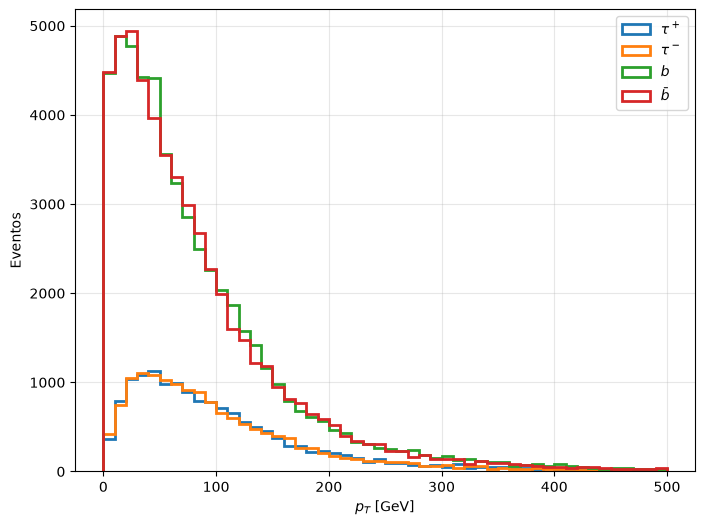

In [12]:
# Seleccionar únicamente los tau+
pt_tau_plus = pt[pid == -15]
pt_tau_minus = pt[pid == 15]

pt_b = pt[pid == 5]
pt_b_bar = pt[pid == -5]

# Unir todos los eventos en un solo vector
pt_antitau = ak.flatten(pt_tau_plus)
pt_tau = ak.flatten(pt_tau_minus)

pt_b = ak.flatten(pt_b)
pt_b_bar = ak.flatten(pt_b_bar)

plt.figure(figsize=(8,6))

plt.hist(ak.to_numpy(pt_antitau),bins=50,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^+$")
plt.hist(ak.to_numpy(pt_tau),bins=50,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^-$")

plt.hist(ak.to_numpy(pt_b),bins=50,range=(0,500),histtype="step",linewidth=2,label=r"$b$")
plt.hist(ak.to_numpy(pt_b_bar),bins=50,range=(0,500),histtype="step",linewidth=2,label=r"$\bar{b}$")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Masas Invariantes

In [ ]:
# Calculo las masas invariantes por parejas y de los 4 elementos:

mass_tautau = (taup + taum).mass
mass_bb = (b + b_bar).mass
mass_hh = (taup + taum + b + b_bar).mass

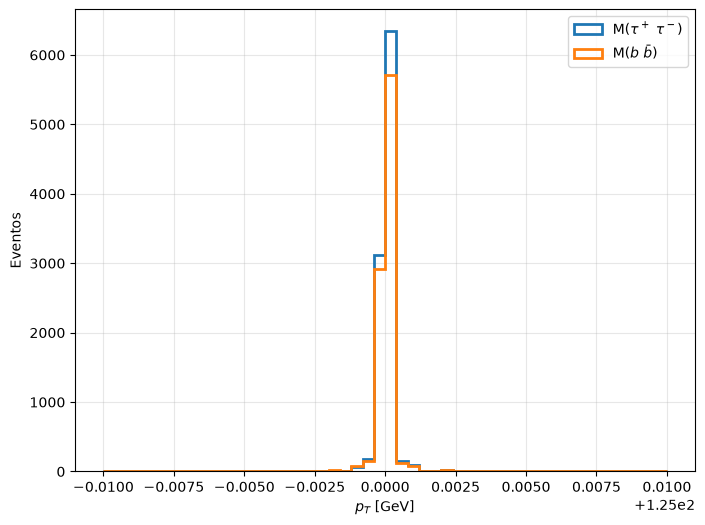

In [33]:
plt.figure(figsize=(8,6))

plt.hist(ak.to_numpy(mass_tautau),bins=50,range=(124.99,125.01),histtype="step",linewidth=2,label=r"M($\tau^+$ $\tau^-$)")
plt.hist(ak.to_numpy(mass_bb),bins=50,range=(124.99,125.01),histtype="step",linewidth=2,label=r"M($b$ $\bar{b}$)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

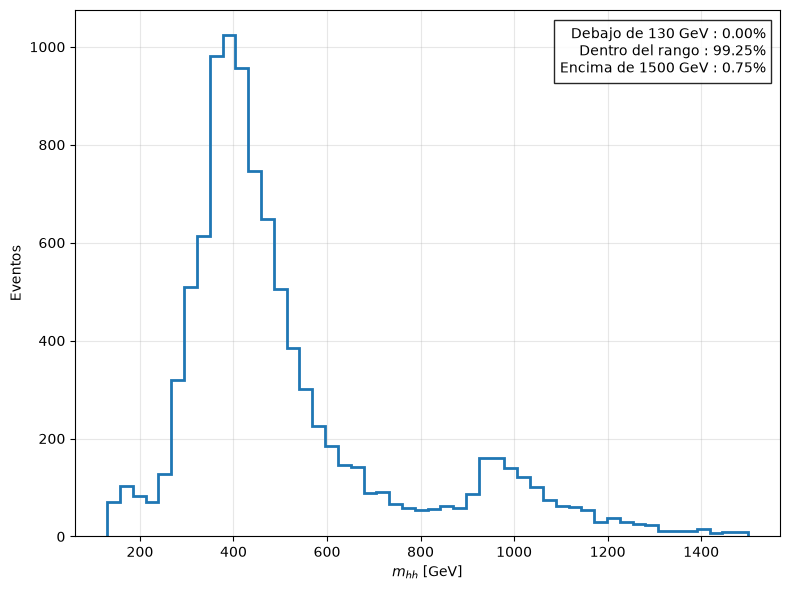

In [30]:
# Convertir a NumPy
m = ak.to_numpy(mass_hh)

# Definir rango
lim_inf = 130
lim_sup = 1500

# Calcular porcentajes
N = len(m)

debajo = np.sum(m < lim_inf)
dentro = np.sum((m >= lim_inf) & (m <= lim_sup))
encima = np.sum(m > lim_sup)

p_debajo = 100 * debajo / N
p_dentro = 100 * dentro / N
p_encima = 100 * encima / N

# Histograma
plt.figure(figsize=(8,6))

plt.hist(
    m,
    bins=50,
    range=(lim_inf, lim_sup),
    histtype="step",
    linewidth=2,
)

plt.xlabel(r"$m_{hh}$ [GeV]")
plt.ylabel("Eventos")

# Escribir porcentajes
texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Delta R

In [ ]:
# Armo los vectores de cada particula

taup = vec.zip({
"px": px_tau[:,0],
"py": py_tau[:,0],
"pz": pz_tau[:,0],
"E":  E_tau[:,0],
})

taum = vec.zip({
"px": px_antitau[:,0],
"py": py_antitau[:,0],
"pz": pz_antitau[:,0],
"E":  E_antitau[:,0],
})

b = vec.zip({
"px": px_b[:,0],
"py": py_b[:,0],
"pz": pz_b[:,0],
"E":  E_b[:,0],
})

b_bar = vec.zip({
"px": px_b_bar[:,0],
"py": py_b_bar[:,0],
"pz": pz_b_bar[:,0],
"E":  E_b_bar[:,0],
})

In [36]:
DeltaR_tautau = taup.deltaR(taum)
DeltaR_bb = b.deltaR(b_bar)

In [48]:
list_taus_u600 = []
list_bs_u600 = []

list_taus_o800 = []
list_bs_o800 = []

for vec_tau, vec_antitau, vec_b, vec_antib in zip(taum, taup, b, b_bar):

    M = (vec_tau + vec_antitau + vec_b + vec_antib).mass

    if 200 < M < 600:

        DeltaR_tautau_200_600 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_200_600 = vec_b.deltaR(vec_antib)

        list_taus_u600.append(DeltaR_tautau_200_600)
        list_bs_u600.append(DeltaR_bb_200_600)

    elif 800 < M < 1200:

        DeltaR_tautau_800_1200 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_800_1200 = vec_b.deltaR(vec_antib)

        list_taus_o800.append(DeltaR_tautau_800_1200)
        list_bs_o800.append(DeltaR_bb_800_1200)

Como el código tarda unos minutos, ya guardo en un .dat:

In [50]:
# Guardar región 200 < M < 600 GeV
data_u600 = np.column_stack((
    list_taus_u600,
    list_bs_u600
))

np.savetxt(
    "DeltaR_200_600.dat",
    data_u600,
    header="DeltaR_tautau    DeltaR_bb",
    fmt="%.6f"
)


# Guardar región 800 < M < 1200 GeV
data_o800 = np.column_stack((
    list_taus_o800,
    list_bs_o800
))

np.savetxt(
    "DeltaR_800_1200.dat",
    data_o800,
    header="DeltaR_tautau    DeltaR_bb",
    fmt="%.6f"
)

In [ ]:
list_u600 = pd.pandas.read_csv("DeltaR_200_600.dat", comment="#", sep = r"\s+", names=["DeltaR_tautau", "DeltaR_bb"])
list_o800 = pd.pandas.read_csv("DeltaR_800_1200.dat", comment="#", sep = r"\s+", names=["DeltaR_tautau", "DeltaR_bb"])

taus_u600 = list_u600["DeltaR_tautau"].values
taus_o800 = list_o800["DeltaR_tautau"].values

b_u600 = list_u600["DeltaR_bb"].values
b_o800 = list_o800["DeltaR_bb"].values

DeltaR_tautau = taup.deltaR(taum)
DeltaR_bb = b.deltaR(b_bar)

In [ ]:

plt.figure(figsize=(8,6))

plt.hist(
    ak.to_numpy(DeltaR_tautau),
    bins=50,
    range=(0,6),
    histtype="step",
    color = 'blue',
    linewidth=2,
    label=r"Without cut"
)

plt.hist(
    taus_u600,
    bins=50,
    range=(0,6),
    histtype="step",
    linewidth=2,
    color = 'red',
    label=r"$200<m_{hh}<600$ GeV"
)

plt.hist(
    taus_o800,
    bins=50,
    range=(0,6),
    histtype="step",
    linewidth=2,
    color = 'green',
    label=r"$800<m_{hh}<1200$ GeV"
)


plt.xlabel(r"$\Delta R(\tau^+,\tau^-)$")
plt.ylabel("Eventos")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'DeltaR_tautau'

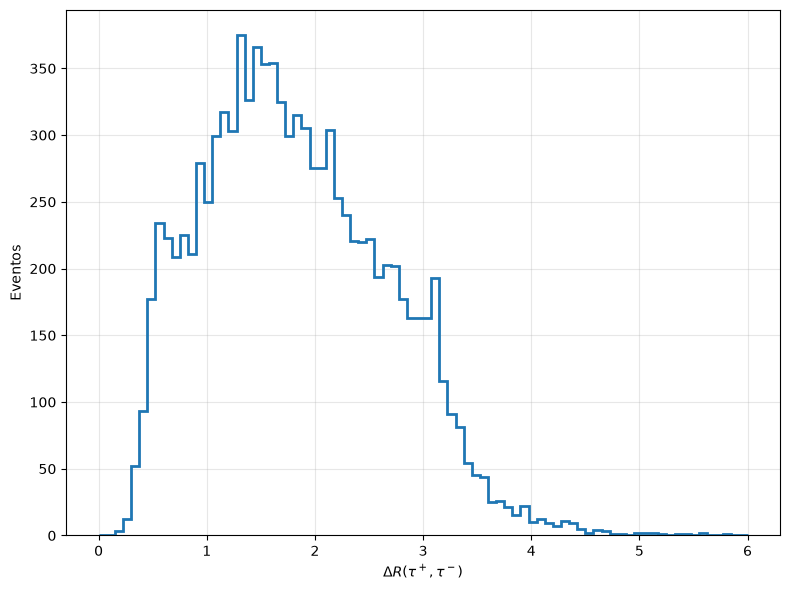

In [40]:
plt.figure(figsize=(8,6))

plt.hist(
    ak.to_numpy(DeltaR_tautau),
    bins=80,
    range=(0,6),
    histtype="step",
    linewidth=2
)

plt.xlabel(r"$\Delta R(\tau^+,\tau^-)$")
plt.ylabel("Eventos")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()